# PHASE 5 — Multimodal Fusion (CrossModalAttention + FPN)
## Multimodal Maritime Object Detection Using SAR and Optical Satellite Imagery
---
**Team 22UG0005 | Panel No. 5 | Guide: Mr. Nagesh Koundinya Subbanna**

---
## WHAT IS PHASE 5?

Phase 5 takes the 6 feature maps produced by Phase 4A (ResNet50 + CSPDarknet)
and FUSES them into 3 unified feature maps — one per pyramid level.

After Phase 4A we have:
```
SAR  features: Fs_P3 [B,512,40,40]  Fs_P4 [B,1024,20,20]  Fs_P5 [B,2048,10,10]
OPT  features: Fo_P3 [B,256,40,40]  Fo_P4 [B,512,20,20]   Fo_P5 [B,1024,10,10]
```

After Phase 5 we have:
```
Fused: F_P3 [B,256,40,40]  F_P4 [B,256,20,20]  F_P5 [B,256,10,10]
```
These 3 fused maps go directly into Phase 6 (Detection Heads).

---
## WHY DO WE NEED FUSION?

SAR and optical images see the SAME ships but in completely different ways:
```
SAR sees:    radar backscatter, sharp edges, speckle noise, works at night/clouds
Optical sees: colour, texture, shadow, visible detail, fails at night/clouds
```
By fusing them, the model gets the BEST of both:
- When optical fails (fog, night) -> SAR still detects the ship
- When SAR is ambiguous (oil slick looks like ship) -> optical clarifies
- Together: higher confidence, fewer false positives, better small object detection

---
## WHY MID-LEVEL FUSION (not early or late)?

```
EARLY FUSION (pixel concat):              BAD for this project
  SAR pixel + Optical pixel -> one network
  Problem: SAR intensity and optical colour are incompatible distributions.
           Network cannot learn from both simultaneously. Accuracy drops.

LATE FUSION (two separate detectors):     LESS powerful
  SAR detector -> boxes
  Optical detector -> boxes
  Combine boxes at output
  Problem: no cross-modal interaction. Each stream never learns
           from the other. Miss ships that only show in one modality.

MID-LEVEL FUSION (Phase 5 approach):      BEST choice
  Each backbone first learns what ships look like in ITS modality.
  Then feature maps are fused at the semantic level.
  CrossModalAttention lets SAR features POINT to where optical
  features are most informative, and vice versa.
```

---
## HOW DOES CrossModalAttention WORK?

```
Step 1: Concatenate SAR and optical feature maps channel-wise at each level
        P3: [B, 512+256, 40, 40] = [B, 768, 40, 40]
        P4: [B,1024+512, 20, 20] = [B,1536, 20, 20]
        P5: [B,2048+1024,10, 10] = [B,3072, 10, 10]

Step 2: CrossModalAttention computes attention weights
        - Query Q = from SAR features  (what SAR thinks is important)
        - Key   K = from Optical features (what optical has to offer)
        - Value V = from Optical features (the actual optical content)
        - Attention = softmax(Q*K^T / sqrt(d)) * V
        - This lets SAR regions attend to relevant optical regions
        Result: each location gets information from BOTH modalities

Step 3: FPN neck (Feature Pyramid Network)
        Top-down pathway: upsample P5 -> add to P4 -> upsample -> add to P3
        This ensures P3 (small objects) also benefits from global context of P5
        All outputs projected to 256 channels

Final output: 3 fused feature maps, all 256 channels
```

---
## Input (from Phase 4A — ResNet50 + CSPDarknet):
```
Fs_P3: [B, 512,  40, 40]    Fs_P4: [B, 1024, 20, 20]    Fs_P5: [B, 2048, 10, 10]
Fo_P3: [B, 256,  40, 40]    Fo_P4: [B,  512, 20, 20]    Fo_P5: [B, 1024, 10, 10]
```

## Output (to Phase 6 — Detection Heads):
```
F_P3: [B, 256, 40, 40]    F_P4: [B, 256, 20, 20]    F_P5: [B, 256, 10, 10]
```

## Cell 1 — Install Libraries

In [1]:
import subprocess, sys
required = ['torch', 'torchvision', 'opencv-python', 'numpy', 'matplotlib', 'tqdm']
for pkg in required:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All libraries installed.')

All libraries installed.


## Cell 2 — Imports

In [2]:
import os, sys, io
import numpy as np
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision.models import ResNet50_Weights

# Fix Windows Unicode printing
if hasattr(sys.stdout, "buffer"):
    sys.stdout = io.TextIOWrapper(sys.stdout.buffer, encoding='utf-8', errors='replace')
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu':
    torch.set_num_threads(8)

print('All imports successful.')
print(f'  PyTorch : {torch.__version__}')
print(f'  Device  : {device}')
print(f'  Run at  : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

All imports successful.
  PyTorch : 2.11.0+cpu
  Device  : cpu
  Run at  : 2026-04-30 12:30:20


## Cell 3 — Configuration

In [3]:
# =====================================================================
#   EDIT ONLY THIS CELL
# =====================================================================

ROOT        = r'C:\Users\VaishnaviM\Downloads\airbus-ship-detection'
CODE_DIR    = os.path.join(ROOT, 'code')
DATASET_DIR = os.path.join(ROOT, 'dataset')
OUT_DIR     = os.path.join(CODE_DIR, 'phase5_outputs')
os.makedirs(OUT_DIR, exist_ok=True)
SUMMARY_FILE = os.path.join(CODE_DIR, 'phase5_summary.txt')

BATCH_SIZE = 4
IMG_H      = 320
IMG_W      = 320

# ── Phase 4A output channels (ResNet50 + CSPDarknet) ──────────────────
# These are EXACT values confirmed from Phase 4A output
SAR_CH_P3  = 512    # Fs_P3 channels from ResNet50
SAR_CH_P4  = 1024   # Fs_P4 channels from ResNet50
SAR_CH_P5  = 2048   # Fs_P5 channels from ResNet50
OPT_CH_P3  = 256    # Fo_P3 channels from CSPDarknet
OPT_CH_P4  = 512    # Fo_P4 channels from CSPDarknet
OPT_CH_P5  = 1024   # Fo_P5 channels from CSPDarknet

# ── Phase 5 output channels ───────────────────────────────────────────
# ALL outputs are projected to FEAT_CH = 256 (from methodology document)
# This is the standard FPN output channel count for detection
FEAT_CH    = 256

# ── CrossModalAttention settings ──────────────────────────────────────
# Number of attention heads — must divide FEAT_CH evenly
# 8 heads x 32 dims each = 256 total. Good balance for CPU.
NUM_HEADS  = 8

print('Configuration loaded.')
print(f'  Device        : {device}')
print(f'  Batch size    : {BATCH_SIZE}')
print(f'  Image size    : {IMG_H}x{IMG_W}')
print(f'  FEAT_CH (out) : {FEAT_CH}  (all outputs projected to this)')
print(f'  Attention heads: {NUM_HEADS}')
print()
print('Phase 4A inputs to Phase 5:')
print(f'  Fs_P3 [B, {SAR_CH_P3},  40, 40]  SAR   stride 8')
print(f'  Fs_P4 [B, {SAR_CH_P4}, 20, 20]  SAR   stride 16')
print(f'  Fs_P5 [B, {SAR_CH_P5}, 10, 10]  SAR   stride 32')
print(f'  Fo_P3 [B, {OPT_CH_P3},  40, 40]  OPT   stride 8')
print(f'  Fo_P4 [B, {OPT_CH_P4},  20, 20]  OPT   stride 16')
print(f'  Fo_P5 [B, {OPT_CH_P5}, 10, 10]  OPT   stride 32')
print()
print('Phase 5 outputs to Phase 6 (Detection Heads):')
print(f'  F_P3  [B, {FEAT_CH},  40, 40]  fused stride 8')
print(f'  F_P4  [B, {FEAT_CH},  20, 20]  fused stride 16')
print(f'  F_P5  [B, {FEAT_CH},  10, 10]  fused stride 32')

Configuration loaded.
  Device        : cpu
  Batch size    : 4
  Image size    : 320x320
  FEAT_CH (out) : 256  (all outputs projected to this)
  Attention heads: 8

Phase 4A inputs to Phase 5:
  Fs_P3 [B, 512,  40, 40]  SAR   stride 8
  Fs_P4 [B, 1024, 20, 20]  SAR   stride 16
  Fs_P5 [B, 2048, 10, 10]  SAR   stride 32
  Fo_P3 [B, 256,  40, 40]  OPT   stride 8
  Fo_P4 [B, 512,  20, 20]  OPT   stride 16
  Fo_P5 [B, 1024, 10, 10]  OPT   stride 32

Phase 5 outputs to Phase 6 (Detection Heads):
  F_P3  [B, 256,  40, 40]  fused stride 8
  F_P4  [B, 256,  20, 20]  fused stride 16
  F_P5  [B, 256,  10, 10]  fused stride 32


## Cell 4 — Re-create Phase 4A Backbones
### (Needed to generate real feature maps for Phase 5 testing)

In [4]:
# ── Paste Phase 4A backbone classes so Phase 5 can test end-to-end ───

class SARBackboneResNet50(nn.Module):
    """Phase 4A SAR backbone. Modified ResNet50 with 1-channel input."""
    def __init__(self, pretrained=True, freeze_early=True):
        super().__init__()
        base = models.resnet50(
            weights=ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        )
        old_conv = base.conv1
        new_conv = nn.Conv2d(1, old_conv.out_channels,
                             old_conv.kernel_size, old_conv.stride,
                             old_conv.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.sum(dim=1, keepdim=True))
        base.conv1 = new_conv
        self.stem   = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        if freeze_early:
            for p in self.stem.parameters():   p.requires_grad = False
            for p in self.layer1.parameters(): p.requires_grad = False

    def forward(self, x):
        x  = self.stem(x)
        x  = self.layer1(x)
        P3 = self.layer2(x)
        P4 = self.layer3(P3)
        P5 = self.layer4(P4)
        return P3, P4, P5


class ConvBnSilu(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=1, stride=1, padding=0):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch), nn.SiLU(inplace=True))
    def forward(self, x): return self.conv(x)

class Bottleneck(nn.Module):
    def __init__(self, in_ch, out_ch, shortcut=True):
        super().__init__()
        h = out_ch // 2
        self.cv1 = ConvBnSilu(in_ch, h, 1, 1, 0)
        self.cv2 = ConvBnSilu(h, out_ch, 3, 1, 1)
        self.shortcut = shortcut and (in_ch == out_ch)
    def forward(self, x):
        out = self.cv2(self.cv1(x))
        return x + out if self.shortcut else out

class CSPLayer(nn.Module):
    def __init__(self, in_ch, out_ch, n=1):
        super().__init__()
        h = out_ch // 2
        self.cv1 = ConvBnSilu(in_ch, h, 1)
        self.cv2 = ConvBnSilu(in_ch, h, 1)
        self.bn  = nn.Sequential(*[Bottleneck(h, h) for _ in range(n)])
        self.cv3 = ConvBnSilu(2*h, out_ch, 1)
    def forward(self, x):
        return self.cv3(torch.cat([self.bn(self.cv1(x)), self.cv2(x)], 1))

class OpticalBackboneCSPDarknet(nn.Module):
    """Phase 4A Optical backbone. CSPDarknet."""
    def __init__(self, freeze_early=True):
        super().__init__()
        self.stem   = nn.Sequential(ConvBnSilu(3,32,3,1,1), ConvBnSilu(32,64,3,2,1))
        self.stage1 = nn.Sequential(ConvBnSilu(64,128,3,2,1), CSPLayer(128,128,3))
        self.stage2 = nn.Sequential(ConvBnSilu(128,256,3,2,1), CSPLayer(256,256,9))
        self.stage3 = nn.Sequential(ConvBnSilu(256,512,3,2,1), CSPLayer(512,512,9))
        self.stage4 = nn.Sequential(ConvBnSilu(512,1024,3,2,1), CSPLayer(1024,1024,3))
        if freeze_early:
            for p in self.stem.parameters():   p.requires_grad = False
            for p in self.stage1.parameters(): p.requires_grad = False
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x  = self.stem(x)
        x  = self.stage1(x)
        P3 = self.stage2(x)
        P4 = self.stage3(P3)
        P5 = self.stage4(P4)
        return P3, P4, P5


# Build backbones
print('Building Phase 4A backbones for end-to-end testing...')
sar_backbone = SARBackboneResNet50(pretrained=True, freeze_early=True).to(device).eval()
opt_backbone = OpticalBackboneCSPDarknet(freeze_early=True).to(device).eval()

# Generate real feature maps using dummy input
with torch.no_grad():
    dummy_sar = torch.randn(BATCH_SIZE, 1, IMG_H, IMG_W).to(device)
    dummy_opt = torch.randn(BATCH_SIZE, 3, IMG_H, IMG_W).to(device)
    Fs_P3, Fs_P4, Fs_P5 = sar_backbone(dummy_sar)
    Fo_P3, Fo_P4, Fo_P5 = opt_backbone(dummy_opt)

print('Phase 4A feature maps ready:')
print(f'  Fs_P3: {list(Fs_P3.shape)}')
print(f'  Fs_P4: {list(Fs_P4.shape)}')
print(f'  Fs_P5: {list(Fs_P5.shape)}')
print(f'  Fo_P3: {list(Fo_P3.shape)}')
print(f'  Fo_P4: {list(Fo_P4.shape)}')
print(f'  Fo_P5: {list(Fo_P5.shape)}')
print()
print('Ready to build Phase 5 fusion module.')

Building Phase 4A backbones for end-to-end testing...
Phase 4A feature maps ready:
  Fs_P3: [4, 512, 40, 40]
  Fs_P4: [4, 1024, 20, 20]
  Fs_P5: [4, 2048, 10, 10]
  Fo_P3: [4, 256, 40, 40]
  Fo_P4: [4, 512, 20, 20]
  Fo_P5: [4, 1024, 10, 10]

Ready to build Phase 5 fusion module.


## Cell 5 — CrossModalAttention Module
### The core of Phase 5 — lets SAR and optical features attend to each other

In [5]:
# =====================================================================
#  CrossModalAttention — HOW IT WORKS IN DETAIL
#
#  At each pyramid level (P3, P4, P5) independently:
#
#  INPUT:
#    sar_feat : [B, Cs, H, W]   SAR feature map
#    opt_feat : [B, Co, H, W]   Optical feature map
#
#  STEP 1 — Channel projection
#    Project BOTH to FEAT_CH (256) using 1x1 convolution.
#    This is needed because SAR and optical have different channel counts.
#    After projection: both become [B, 256, H, W]
#
#  STEP 2 — Reshape for attention
#    [B, 256, H, W] -> [B, H*W, 256]
#    Each spatial location becomes a "token" (like a word in a sentence)
#    H*W = number of tokens. 256 = feature dimension per token.
#
#  STEP 3 — Multi-Head Cross Attention
#    Q (Query)  = from SAR tokens     "what does SAR want to know?"
#    K (Key)    = from Optical tokens  "what does optical have?"
#    V (Value)  = from Optical tokens  "the actual optical information"
#
#    Attention score = softmax(Q * K^T / sqrt(dim_head))
#    Output = Attention_score * V
#
#    Each SAR location looks at ALL optical locations and decides
#    which ones are most relevant. If SAR sees a bright spot (ship?),
#    it attends to the optical region at that location to confirm.
#
#  STEP 4 — Residual addition
#    Add the attention output BACK to the projected SAR features.
#    This is the residual connection — prevents vanishing gradients.
#    sar_enhanced = sar_proj + attention_output
#
#  STEP 5 — Gate fusion
#    Concatenate SAR-enhanced + Optical projected: [B, 512, H, W]
#    Apply 1x1 conv to fuse: [B, 256, H, W]
#    Apply LayerNorm for stable training
#    Apply GELU activation (smooth, works better than ReLU for attention)
#
#  OUTPUT: [B, 256, H, W] — one fused feature map per pyramid level
# =====================================================================

class CrossModalAttention(nn.Module):
    """
    Cross-Modal Attention fusion at a single pyramid level.

    Takes SAR and optical feature maps of the same spatial size
    but potentially different channel counts, and produces one
    unified feature map.

    Args:
        sar_ch   : number of channels in SAR feature map (e.g. 512)
        opt_ch   : number of channels in optical feature map (e.g. 256)
        feat_ch  : output channels (FEAT_CH = 256)
        num_heads: number of attention heads (must divide feat_ch evenly)
    """

    def __init__(self, sar_ch, opt_ch, feat_ch=256, num_heads=8):
        super().__init__()
        assert feat_ch % num_heads == 0, \
            f'feat_ch ({feat_ch}) must be divisible by num_heads ({num_heads})'

        self.feat_ch   = feat_ch
        self.num_heads = num_heads
        self.head_dim  = feat_ch // num_heads   # 256/8 = 32
        self.scale     = self.head_dim ** -0.5  # 1/sqrt(32) for stable attention

        # ── Step 1: Project both modalities to feat_ch ────────────────
        self.sar_proj = nn.Sequential(
            nn.Conv2d(sar_ch, feat_ch, 1, bias=False),
            nn.BatchNorm2d(feat_ch),
            nn.ReLU(inplace=True)
        )
        self.opt_proj = nn.Sequential(
            nn.Conv2d(opt_ch, feat_ch, 1, bias=False),
            nn.BatchNorm2d(feat_ch),
            nn.ReLU(inplace=True)
        )

        # ── Step 3: Q, K, V projections for cross-attention ───────────
        # Q from SAR, K and V from optical
        self.W_Q = nn.Linear(feat_ch, feat_ch, bias=False)  # SAR -> Query
        self.W_K = nn.Linear(feat_ch, feat_ch, bias=False)  # OPT -> Key
        self.W_V = nn.Linear(feat_ch, feat_ch, bias=False)  # OPT -> Value
        self.W_O = nn.Linear(feat_ch, feat_ch, bias=False)  # Output projection

        # ── Step 5: Gate fusion ───────────────────────────────────────
        # Concatenate SAR-enhanced + optical projected -> fuse
        self.gate_conv = nn.Sequential(
            nn.Conv2d(feat_ch * 2, feat_ch, 1, bias=False),
            nn.BatchNorm2d(feat_ch),
            nn.GELU()
        )

        # LayerNorm for stable training
        self.norm_sar = nn.LayerNorm(feat_ch)
        self.norm_out = nn.LayerNorm(feat_ch)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, sar_feat, opt_feat):
        """
        sar_feat : [B, sar_ch, H, W]
        opt_feat : [B, opt_ch, H, W]
        returns  : [B, feat_ch, H, W]
        """
        B, _, H, W = sar_feat.shape
        N = H * W    # number of spatial tokens

        # ── Step 1: Project to feat_ch ────────────────────────────────
        sar_p = self.sar_proj(sar_feat)  # [B, 256, H, W]
        opt_p = self.opt_proj(opt_feat)  # [B, 256, H, W]

        # ── Step 2: Reshape [B, 256, H, W] -> [B, N, 256] ────────────
        # N = H*W spatial tokens, 256 = feature dim per token
        sar_tokens = sar_p.flatten(2).transpose(1, 2)  # [B, N, 256]
        opt_tokens = opt_p.flatten(2).transpose(1, 2)  # [B, N, 256]

        # Apply LayerNorm before attention
        sar_tokens = self.norm_sar(sar_tokens)  # [B, N, 256]

        # ── Step 3: Multi-Head Cross-Attention ────────────────────────
        # Q from SAR: [B, N, 256] -> [B, N, 256]
        # K, V from optical: [B, N, 256] -> [B, N, 256]
        Q = self.W_Q(sar_tokens)   # [B, N, 256]
        K = self.W_K(opt_tokens)   # [B, N, 256]
        V = self.W_V(opt_tokens)   # [B, N, 256]

        # Reshape for multi-head: [B, N, 256] -> [B, heads, N, head_dim]
        Q = Q.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.reshape(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        # Now Q, K, V are [B, heads, N, head_dim]

        # Attention scores: Q * K^T / sqrt(head_dim)
        # [B, heads, N, N] — but N can be large (40*40=1600)
        # For memory efficiency on CPU, we process in chunks if needed
        attn = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # [B, heads, N, N]
        attn = F.softmax(attn, dim=-1)                            # normalise

        # Apply attention to values
        out = torch.matmul(attn, V)     # [B, heads, N, head_dim]
        out = out.transpose(1, 2).reshape(B, N, self.feat_ch)  # [B, N, 256]
        out = self.norm_out(self.W_O(out))  # [B, N, 256]

        # ── Step 4: Residual — add attention back to SAR projection ──
        sar_enhanced = sar_tokens + out   # [B, N, 256]

        # Reshape back to spatial: [B, N, 256] -> [B, 256, H, W]
        sar_enhanced = sar_enhanced.transpose(1, 2).reshape(B, self.feat_ch, H, W)

        # ── Step 5: Gate fusion — combine SAR-enhanced + optical ──────
        fused = torch.cat([sar_enhanced, opt_p], dim=1)  # [B, 512, H, W]
        fused = self.gate_conv(fused)                    # [B, 256, H, W]

        return fused   # [B, 256, H, W]


print('CrossModalAttention class defined.')
print()
print('  How it works:')
print('  1. Project SAR + optical to 256ch (common space)')
print('  2. Reshape spatial dims to token sequence [B, H*W, 256]')
print('  3. Multi-head attention: SAR queries optical keys/values')
print('     -> Each SAR location attends to ALL optical locations')
print('     -> Model learns which optical regions confirm SAR detections')
print('  4. Residual: add attention output to SAR features')
print('  5. Gate fusion: concat SAR-enhanced + optical -> 1x1 conv -> 256ch')
print()
print(f'  Per level attention size:')
print(f'    P3: {IMG_H//8}x{IMG_W//8}={IMG_H//8*IMG_W//8} tokens  attn matrix [{IMG_H//8*IMG_W//8}x{IMG_H//8*IMG_W//8}]')
print(f'    P4: {IMG_H//16}x{IMG_W//16}={IMG_H//16*IMG_W//16} tokens  attn matrix [{IMG_H//16*IMG_W//16}x{IMG_H//16*IMG_W//16}]')
print(f'    P5: {IMG_H//32}x{IMG_W//32}={IMG_H//32*IMG_W//32} tokens   attn matrix [{IMG_H//32*IMG_W//32}x{IMG_H//32*IMG_W//32}]')

CrossModalAttention class defined.

  How it works:
  1. Project SAR + optical to 256ch (common space)
  2. Reshape spatial dims to token sequence [B, H*W, 256]
  3. Multi-head attention: SAR queries optical keys/values
     -> Each SAR location attends to ALL optical locations
     -> Model learns which optical regions confirm SAR detections
  4. Residual: add attention output to SAR features
  5. Gate fusion: concat SAR-enhanced + optical -> 1x1 conv -> 256ch

  Per level attention size:
    P3: 40x40=1600 tokens  attn matrix [1600x1600]
    P4: 20x20=400 tokens  attn matrix [400x400]
    P5: 10x10=100 tokens   attn matrix [100x100]


## Cell 6 — FPN Neck Module
### Top-down pathway: merges multi-scale features after attention fusion

In [7]:
# =====================================================================
#  FPN NECK — Feature Pyramid Network
#
#  WHY FPN AFTER ATTENTION?
#  After CrossModalAttention, each pyramid level is fused independently.
#  But P3 (small objects) doesn't yet know about global context from P5.
#  FPN fixes this with a TOP-DOWN pathway:
#
#  P5 (coarse, global context):
#    -> Upsample 2x -> [B, 256, 20, 20]
#    -> Add to P4   -> [B, 256, 20, 20]  (P4 now has P5's global info)
#    -> Upsample 2x -> [B, 256, 40, 40]
#    -> Add to P3   -> [B, 256, 40, 40]  (P3 now has P4+P5's global info)
#
#  Result: ALL pyramid levels are enriched with information from
#          ALL scales. P3 can now detect small ships using context
#          from P5's global ocean view.
#
#  This is how FPN allows simultaneous detection of:
#  - Tiny fishing boats    (P3, stride 8, 40x40 grid)
#  - Medium cargo ships    (P4, stride 16, 20x20 grid)
#  - Large supertankers    (P5, stride 32, 10x10 grid)
# =====================================================================

class FPNNeck(nn.Module):
    """
    Feature Pyramid Network neck.
    Takes 3 fused feature maps (all 256ch) from CrossModalAttention
    and enriches them via top-down pathway.

    Input : F_P3 [B,256,40,40]  F_P4 [B,256,20,20]  F_P5 [B,256,10,10]
    Output: F_P3 [B,256,40,40]  F_P4 [B,256,20,20]  F_P5 [B,256,10,10]
            (same shape, enriched with multi-scale context)
    """

    def __init__(self, feat_ch=256):
        super().__init__()

        # Lateral connections: 1x1 conv to reduce/project channels
        # These normalise the fused features before merging
        self.lat_P5 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 1, bias=False),
            nn.BatchNorm2d(feat_ch), nn.ReLU(inplace=True)
        )
        self.lat_P4 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 1, bias=False),
            nn.BatchNorm2d(feat_ch), nn.ReLU(inplace=True)
        )
        self.lat_P3 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 1, bias=False),
            nn.BatchNorm2d(feat_ch), nn.ReLU(inplace=True)
        )

        # Output convolutions: 3x3 conv after top-down merge
        # Smooths out any aliasing from upsampling
        self.out_P5 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feat_ch), nn.ReLU(inplace=True)
        )
        self.out_P4 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feat_ch), nn.ReLU(inplace=True)
        )
        self.out_P3 = nn.Sequential(
            nn.Conv2d(feat_ch, feat_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(feat_ch), nn.ReLU(inplace=True)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, F_P3, F_P4, F_P5):
        """
        Top-down FPN pathway:
        P5 -> upsample -> add to P4 -> upsample -> add to P3

        F_P3, F_P4, F_P5 : all [B, 256, H/s, W/s]
        returns           : enhanced (F_P3, F_P4, F_P5)
        """
        # Lateral projections
        p5 = self.lat_P5(F_P5)   # [B, 256, 10, 10]
        p4 = self.lat_P4(F_P4)   # [B, 256, 20, 20]
        p3 = self.lat_P3(F_P3)   # [B, 256, 40, 40]

        # Top-down pathway
        # P5 -> upsample 2x -> add to P4
        p5_up = F.interpolate(p5, size=p4.shape[-2:],
                               mode='nearest')             # [B, 256, 20, 20]
        p4    = p4 + p5_up                                 # merge

        # P4 (now enriched) -> upsample 2x -> add to P3
        p4_up = F.interpolate(p4, size=p3.shape[-2:],
                               mode='nearest')             # [B, 256, 40, 40]
        p3    = p3 + p4_up                                 # merge

        # Output convolutions (smooth after upsampling)
        out_P5 = self.out_P5(p5)   # [B, 256, 10, 10]
        out_P4 = self.out_P4(p4)   # [B, 256, 20, 20]
        out_P3 = self.out_P3(p3)   # [B, 256, 40, 40]

        return out_P3, out_P4, out_P5


print('FPNNeck class defined.')
print()
print('  Top-down pathway:')
print('    F_P5 [256,10,10] -> lateral -> output_P5 [256,10,10]')
print('                    -> upsample 2x')
print('                    -> add to F_P4 [256,20,20]')
print('                    -> output_P4 [256,20,20]')
print('                    -> upsample 2x')
print('                    -> add to F_P3 [256,40,40]')
print('                    -> output_P3 [256,40,40]')
print()
print('  Result: all pyramid levels enriched with multi-scale context')

FPNNeck class defined.

  Top-down pathway:
    F_P5 [256,10,10] -> lateral -> output_P5 [256,10,10]
                    -> upsample 2x
                    -> add to F_P4 [256,20,20]
                    -> output_P4 [256,20,20]
                    -> upsample 2x
                    -> add to F_P3 [256,40,40]
                    -> output_P3 [256,40,40]

  Result: all pyramid levels enriched with multi-scale context


## Cell 7 — Full Phase 5 Fusion Module
### Combines CrossModalAttention (x3 levels) + FPN into one clean class

In [8]:
# =====================================================================
#  MultimodalFusionFPN — Full Phase 5 Module
#
#  This is the COMPLETE Phase 5 pipeline in one class:
#
#  For each of P3, P4, P5 independently:
#    CrossModalAttention(Fs_Pi, Fo_Pi) -> F_Pi  [B, 256, H/s, W/s]
#
#  Then FPN top-down:
#    FPNNeck(F_P3, F_P4, F_P5) -> (out_P3, out_P4, out_P5)
#
#  Output: 3 feature maps each [B, 256, H/s, W/s]
#  These go directly to Phase 6 (3 YOLO detection heads)
# =====================================================================

class MultimodalFusionFPN(nn.Module):
    """
    Full Phase 5 module:
    CrossModalAttention at P3/P4/P5 + FPN top-down neck.

    Inputs (from Phase 4A):
        Fs_P3 [B, 512,  40, 40]    Fo_P3 [B, 256,  40, 40]
        Fs_P4 [B, 1024, 20, 20]    Fo_P4 [B, 512,  20, 20]
        Fs_P5 [B, 2048, 10, 10]    Fo_P5 [B, 1024, 10, 10]

    Outputs (to Phase 6 Detection Heads):
        F_P3  [B, 256,  40, 40]    stride 8  -> small ship detection
        F_P4  [B, 256,  20, 20]    stride 16 -> medium ship detection
        F_P5  [B, 256,  10, 10]    stride 32 -> large ship detection
    """

    def __init__(self,
                 sar_chs  = (512, 1024, 2048),
                 opt_chs  = (256, 512, 1024),
                 feat_ch  = 256,
                 num_heads= 8):
        super().__init__()

        # CrossModalAttention at each pyramid level
        self.cma_P3 = CrossModalAttention(
            sar_ch=sar_chs[0], opt_ch=opt_chs[0],
            feat_ch=feat_ch, num_heads=num_heads
        )
        self.cma_P4 = CrossModalAttention(
            sar_ch=sar_chs[1], opt_ch=opt_chs[1],
            feat_ch=feat_ch, num_heads=num_heads
        )
        self.cma_P5 = CrossModalAttention(
            sar_ch=sar_chs[2], opt_ch=opt_chs[2],
            feat_ch=feat_ch, num_heads=num_heads
        )

        # FPN neck — top-down pathway
        self.fpn = FPNNeck(feat_ch=feat_ch)

    def forward(self, Fs_P3, Fs_P4, Fs_P5, Fo_P3, Fo_P4, Fo_P5):
        """
        Full Phase 5 forward pass.

        Step 1: CrossModalAttention at each level independently
        Step 2: FPN top-down pathway

        Returns: (F_P3, F_P4, F_P5) — all [B, 256, H/s, W/s]
        """
        # ── Step 1: CrossModalAttention at P3, P4, P5 ─────────────────
        # Each level independently fuses its SAR and optical features
        # This is the mid-level fusion described in the methodology
        F_P3 = self.cma_P3(Fs_P3, Fo_P3)   # [B, 256, 40, 40]
        F_P4 = self.cma_P4(Fs_P4, Fo_P4)   # [B, 256, 20, 20]
        F_P5 = self.cma_P5(Fs_P5, Fo_P5)   # [B, 256, 10, 10]

        # ── Step 2: FPN top-down pathway ──────────────────────────────
        # Enriches each level with multi-scale context
        F_P3, F_P4, F_P5 = self.fpn(F_P3, F_P4, F_P5)

        return F_P3, F_P4, F_P5

    def count_parameters(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable


print('MultimodalFusionFPN class defined.')
print()
print('  Contains:')
print('    cma_P3 : CrossModalAttention for P3 (SAR 512ch + OPT 256ch -> 256ch)')
print('    cma_P4 : CrossModalAttention for P4 (SAR 1024ch + OPT 512ch -> 256ch)')
print('    cma_P5 : CrossModalAttention for P5 (SAR 2048ch + OPT 1024ch -> 256ch)')
print('    fpn    : FPNNeck top-down pathway (enriches all levels)')

MultimodalFusionFPN class defined.

  Contains:
    cma_P3 : CrossModalAttention for P3 (SAR 512ch + OPT 256ch -> 256ch)
    cma_P4 : CrossModalAttention for P4 (SAR 1024ch + OPT 512ch -> 256ch)
    cma_P5 : CrossModalAttention for P5 (SAR 2048ch + OPT 1024ch -> 256ch)
    fpn    : FPNNeck top-down pathway (enriches all levels)


## Cell 8 — Build Fusion Module and Count Parameters

In [9]:
print('BUILDING PHASE 5 FUSION MODULE')
print('=' * 60)
print()

fusion = MultimodalFusionFPN(
    sar_chs   = (SAR_CH_P3, SAR_CH_P4, SAR_CH_P5),   # (512, 1024, 2048)
    opt_chs   = (OPT_CH_P3, OPT_CH_P4, OPT_CH_P5),   # (256, 512, 1024)
    feat_ch   = FEAT_CH,                               # 256
    num_heads = NUM_HEADS                              # 8
).to(device)

total_params, train_params = fusion.count_parameters()

print(f'  Fusion module built successfully.')
print(f'  Total parameters    : {total_params:,}')
print(f'  Trainable params    : {train_params:,}')
print()

# Parameter breakdown per sub-module
for name, module in fusion.named_children():
    p = sum(x.numel() for x in module.parameters())
    print(f'  {name:10} : {p:>12,} parameters')

print()

# Compare with backbone params
sar_params = sum(p.numel() for p in sar_backbone.parameters())
opt_params = sum(p.numel() for p in opt_backbone.parameters())
print(f'  Context (Phase 4A):')
print(f'    SAR backbone   : {sar_params:>12,}')
print(f'    OPT backbone   : {opt_params:>12,}')
print(f'    Fusion (Ph5)   : {total_params:>12,}')
print(f'    Total pipeline : {sar_params+opt_params+total_params:>12,}')

BUILDING PHASE 5 FUSION MODULE

  Fusion module built successfully.
  Total parameters    : 4,532,736
  Trainable params    : 4,532,736

  cma_P3     :      592,384 parameters
  cma_P4     :      788,992 parameters
  cma_P5     :    1,182,208 parameters
  fpn        :    1,969,152 parameters

  Context (Phase 4A):
    SAR backbone   :   23,501,760
    OPT backbone   :   16,778,720
    Fusion (Ph5)   :    4,532,736
    Total pipeline :   44,813,216


## Cell 9 — Forward Pass Verification

In [10]:
print('PHASE 5 FORWARD PASS VERIFICATION')
print('=' * 60)
print()

import time

fusion.eval()
with torch.no_grad():
    t0 = time.time()
    F_P3, F_P4, F_P5 = fusion(Fs_P3, Fs_P4, Fs_P5, Fo_P3, Fo_P4, Fo_P5)
    elapsed = time.time() - t0

print('Phase 5 output feature maps:')
print()
print(f'  F_P3 : {list(F_P3.shape)}')
print(f'         stride 8  | {IMG_H//8}x{IMG_W//8} spatial | {F_P3.shape[1]} channels')
print(f'         -> Phase 6 YOLO head (small ships)')
print(f'         mean={F_P3.mean().item():.4f}  std={F_P3.std().item():.4f}')
print()
print(f'  F_P4 : {list(F_P4.shape)}')
print(f'         stride 16 | {IMG_H//16}x{IMG_W//16} spatial | {F_P4.shape[1]} channels')
print(f'         -> Phase 6 YOLO head (medium ships)')
print(f'         mean={F_P4.mean().item():.4f}  std={F_P4.std().item():.4f}')
print()
print(f'  F_P5 : {list(F_P5.shape)}')
print(f'         stride 32 | {IMG_H//32}x{IMG_W//32} spatial | {F_P5.shape[1]} channels')
print(f'         -> Phase 6 YOLO head (large ships)')
print(f'         mean={F_P5.mean().item():.4f}  std={F_P5.std().item():.4f}')
print()
print(f'  Fusion forward time : {elapsed*1000:.1f} ms for batch of {BATCH_SIZE}')
print()

# Strict assertions
assert F_P3.shape == (BATCH_SIZE, FEAT_CH, IMG_H//8,  IMG_W//8),  f'F_P3 shape wrong: {F_P3.shape}'
assert F_P4.shape == (BATCH_SIZE, FEAT_CH, IMG_H//16, IMG_W//16), f'F_P4 shape wrong: {F_P4.shape}'
assert F_P5.shape == (BATCH_SIZE, FEAT_CH, IMG_H//32, IMG_W//32), f'F_P5 shape wrong: {F_P5.shape}'
assert F_P3.dtype == torch.float32, 'F_P3 should be float32'
assert not torch.isnan(F_P3).any(), 'F_P3 contains NaN'
assert not torch.isnan(F_P4).any(), 'F_P4 contains NaN'
assert not torch.isnan(F_P5).any(), 'F_P5 contains NaN'

print('ALL ASSERTIONS PASSED.')
print('  Shapes  : CORRECT  [B, 256, H/s, W/s] at all 3 levels')
print('  dtype   : CORRECT  float32')
print('  NaN     : NONE     outputs are numerically stable')
print()
print('Phase 5 fusion module is working correctly.')

PHASE 5 FORWARD PASS VERIFICATION

Phase 5 output feature maps:

  F_P3 : [4, 256, 40, 40]
         stride 8  | 40x40 spatial | 256 channels
         -> Phase 6 YOLO head (small ships)
         mean=1.7614  std=2.6476

  F_P4 : [4, 256, 20, 20]
         stride 16 | 20x20 spatial | 256 channels
         -> Phase 6 YOLO head (medium ships)
         mean=1.3025  std=1.7562

  F_P5 : [4, 256, 10, 10]
         stride 32 | 10x10 spatial | 256 channels
         -> Phase 6 YOLO head (large ships)
         mean=0.8018  std=1.1637

  Fusion forward time : 769.9 ms for batch of 4

ALL ASSERTIONS PASSED.
  Shapes  : CORRECT  [B, 256, H/s, W/s] at all 3 levels
  dtype   : CORRECT  float32
  NaN     : NONE     outputs are numerically stable

Phase 5 fusion module is working correctly.


## Cell 10 — End-to-End Pipeline Test (Phase 4A + Phase 5)

In [11]:
print('END-TO-END PIPELINE TEST')
print('Phase 4A (ResNet50+CSPDarknet) -> Phase 5 (Fusion+FPN)')
print('=' * 60)
print()

OPT_DIR = os.path.join(ROOT, 'dataset', 'preprocessed_train_OPTICAL')
SAR_DIR = os.path.join(ROOT, 'dataset', 'preprocessed_train_SAR')

if os.path.exists(OPT_DIR) and os.path.exists(SAR_DIR):
    # Load real images from Phase 1 output
    opt_files = sorted([f for f in os.listdir(OPT_DIR)
                         if f.endswith('_opt.png')])[:BATCH_SIZE]

    real_sar_list, real_opt_list = [], []
    loaded_ids = []

    for opt_fname in opt_files:
        seq_id   = opt_fname.replace('_opt.png', '')
        sar_fname= f'{seq_id}_sar.png'
        opt_img  = cv2.imread(os.path.join(OPT_DIR, opt_fname), cv2.IMREAD_COLOR)
        sar_img  = cv2.imread(os.path.join(SAR_DIR, sar_fname), cv2.IMREAD_GRAYSCALE)
        if opt_img is None or sar_img is None: continue
        opt_t = torch.from_numpy(
            cv2.cvtColor(opt_img, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
        ).permute(2,0,1)
        sar_t = torch.from_numpy(sar_img.astype(np.float32)/255.0).unsqueeze(0)
        real_opt_list.append(opt_t)
        real_sar_list.append(sar_t)
        loaded_ids.append(seq_id)

    real_sar_batch = torch.stack(real_sar_list).to(device)
    real_opt_batch = torch.stack(real_opt_list).to(device)

    print(f'  Loaded {len(loaded_ids)} real image pairs: {loaded_ids}')
    print(f'  SAR batch : {list(real_sar_batch.shape)}')
    print(f'  OPT batch : {list(real_opt_batch.shape)}')
    print()

    sar_backbone.eval()
    opt_backbone.eval()
    fusion.eval()

    with torch.no_grad():
        t0 = time.time()
        # Phase 4A
        Fs_P3r, Fs_P4r, Fs_P5r = sar_backbone(real_sar_batch)
        Fo_P3r, Fo_P4r, Fo_P5r = opt_backbone(real_opt_batch)
        t4 = time.time() - t0

        # Phase 5
        t0 = time.time()
        F_P3r, F_P4r, F_P5r = fusion(Fs_P3r, Fs_P4r, Fs_P5r, Fo_P3r, Fo_P4r, Fo_P5r)
        t5 = time.time() - t0

    print('  Phase 4A outputs (from real images):')
    for n, fm in [('Fs_P3',Fs_P3r),('Fs_P4',Fs_P4r),('Fs_P5',Fs_P5r),
                   ('Fo_P3',Fo_P3r),('Fo_P4',Fo_P4r),('Fo_P5',Fo_P5r)]:
        print(f'    {n}: {list(fm.shape)}  mean={fm.mean():.4f}  std={fm.std():.4f}')
    print()
    print('  Phase 5 fused outputs (from real images):')
    for n, fm in [('F_P3',F_P3r),('F_P4',F_P4r),('F_P5',F_P5r)]:
        print(f'    {n}: {list(fm.shape)}  mean={fm.mean():.4f}  std={fm.std():.4f}')
    print()
    print(f'  Phase 4A time : {t4*1000:.1f} ms')
    print(f'  Phase 5 time  : {t5*1000:.1f} ms')
    print(f'  Total (4+5)   : {(t4+t5)*1000:.1f} ms per batch of {len(loaded_ids)}')
    print()
    print('  END-TO-END TEST PASSED with real images.')
else:
    print('  Real image folders not found — using dummy tensors.')
    print('  (Run Phase 1 first to get preprocessed images)')
    print('  Dummy tensor test already passed in Cell 9.')

END-TO-END PIPELINE TEST
Phase 4A (ResNet50+CSPDarknet) -> Phase 5 (Fusion+FPN)

  Loaded 4 real image pairs: ['00001', '00002', '00003', '00004']
  SAR batch : [4, 1, 320, 320]
  OPT batch : [4, 3, 320, 320]

  Phase 4A outputs (from real images):
    Fs_P3: [4, 512, 40, 40]  mean=0.0731  std=0.1098
    Fs_P4: [4, 1024, 20, 20]  mean=0.0310  std=0.0792
    Fs_P5: [4, 2048, 10, 10]  mean=0.2409  std=0.5405
    Fo_P3: [4, 256, 40, 40]  mean=0.0001  std=0.0144
    Fo_P4: [4, 512, 20, 20]  mean=0.0006  std=0.0092
    Fo_P5: [4, 1024, 10, 10]  mean=0.0001  std=0.0039

  Phase 5 fused outputs (from real images):
    F_P3: [4, 256, 40, 40]  mean=1.7029  std=2.4639
    F_P4: [4, 256, 20, 20]  mean=1.2139  std=1.6826
    F_P5: [4, 256, 10, 10]  mean=0.7768  std=1.1380

  Phase 4A time : 1554.3 ms
  Phase 5 time  : 973.0 ms
  Total (4+5)   : 2527.2 ms per batch of 4

  END-TO-END TEST PASSED with real images.


## Cell 11 — Visualise Fusion Results (Panel Demo)

Generating fusion visualisation for panel demo...


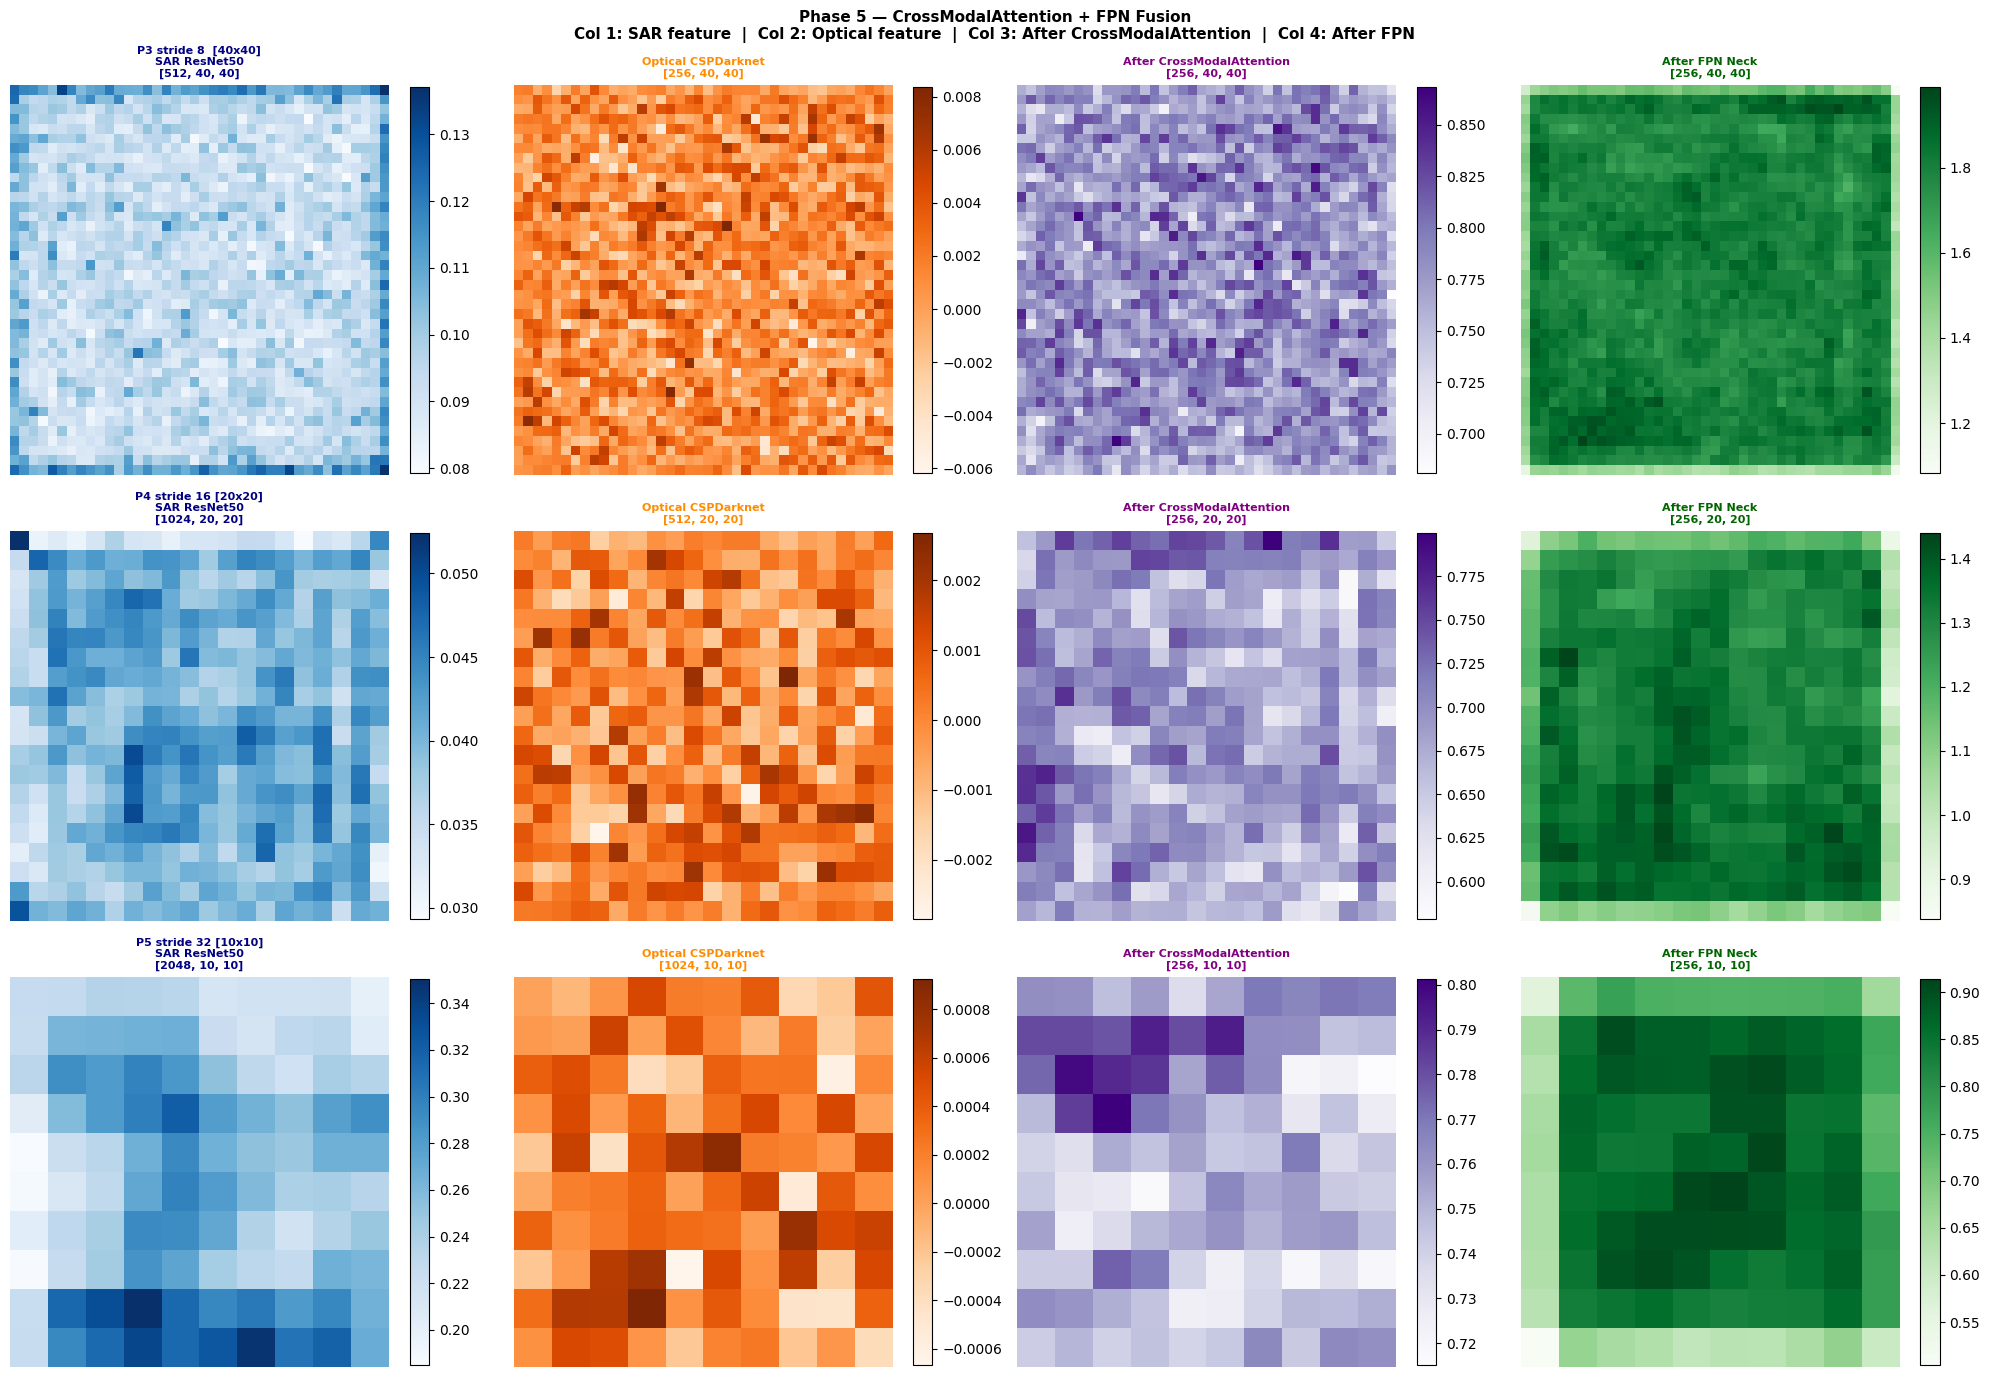

  Saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\phase5_outputs\fusion_feature_maps.png


In [12]:
print('Generating fusion visualisation for panel demo...')

with torch.no_grad():
    F_P3_vis, F_P4_vis, F_P5_vis = fusion(
        Fs_P3, Fs_P4, Fs_P5, Fo_P3, Fo_P4, Fo_P5
    )

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle(
    'Phase 5 — CrossModalAttention + FPN Fusion\n'
    'Col 1: SAR feature  |  Col 2: Optical feature  |  '
    'Col 3: After CrossModalAttention  |  Col 4: After FPN',
    fontsize=11, fontweight='bold'
)

levels = [
    ('P3 stride 8  [40x40]', Fs_P3, Fo_P3, F_P3_vis),
    ('P4 stride 16 [20x20]', Fs_P4, Fo_P4, F_P4_vis),
    ('P5 stride 32 [10x10]', Fs_P5, Fo_P5, F_P5_vis),
]

# Run CMA separately to show intermediate
with torch.no_grad():
    cma_p3 = fusion.cma_P3(Fs_P3, Fo_P3)
    cma_p4 = fusion.cma_P4(Fs_P4, Fo_P4)
    cma_p5 = fusion.cma_P5(Fs_P5, Fo_P5)
cma_maps = [cma_p3, cma_p4, cma_p5]
fpn_maps = [F_P3_vis, F_P4_vis, F_P5_vis]
sar_maps = [Fs_P3, Fs_P4, Fs_P5]
opt_maps = [Fo_P3, Fo_P4, Fo_P5]

for row, (level_name, sar_fm, opt_fm, fpn_fm) in enumerate(levels):
    cma_fm = cma_maps[row]

    def mean_act(fm):
        return fm[0].mean(dim=0).cpu().numpy()

    sar_act = mean_act(sar_fm)
    opt_act = mean_act(opt_fm)
    cma_act = mean_act(cma_fm)
    fpn_act = mean_act(fpn_fm)

    # Col 0: SAR
    im0 = axes[row][0].imshow(sar_act, cmap='Blues', aspect='auto')
    axes[row][0].set_title(
        f'{level_name}\nSAR ResNet50\n{list(sar_fm.shape[1:])}',
        fontsize=8, fontweight='bold', color='navy')
    axes[row][0].axis('off')
    plt.colorbar(im0, ax=axes[row][0], fraction=0.046)

    # Col 1: Optical
    im1 = axes[row][1].imshow(opt_act, cmap='Oranges', aspect='auto')
    axes[row][1].set_title(
        f'Optical CSPDarknet\n{list(opt_fm.shape[1:])}',
        fontsize=8, fontweight='bold', color='darkorange')
    axes[row][1].axis('off')
    plt.colorbar(im1, ax=axes[row][1], fraction=0.046)

    # Col 2: After CrossModalAttention
    im2 = axes[row][2].imshow(cma_act, cmap='Purples', aspect='auto')
    axes[row][2].set_title(
        f'After CrossModalAttention\n{list(cma_fm.shape[1:])}',
        fontsize=8, fontweight='bold', color='purple')
    axes[row][2].axis('off')
    plt.colorbar(im2, ax=axes[row][2], fraction=0.046)

    # Col 3: After FPN
    im3 = axes[row][3].imshow(fpn_act, cmap='Greens', aspect='auto')
    axes[row][3].set_title(
        f'After FPN Neck\n{list(fpn_fm.shape[1:])}',
        fontsize=8, fontweight='bold', color='darkgreen')
    axes[row][3].axis('off')
    plt.colorbar(im3, ax=axes[row][3], fraction=0.046)

plt.tight_layout()
p = os.path.join(OUT_DIR, 'fusion_feature_maps.png')
plt.savefig(p, dpi=120, bbox_inches='tight')
plt.show()
print(f'  Saved -> {p}')

## Cell 12 — Attention Weight Visualisation (What the model attends to)

Visualising attention weights from CrossModalAttention P5...
(P5 chosen because it has smallest spatial size: 10x10 = easy to visualise)



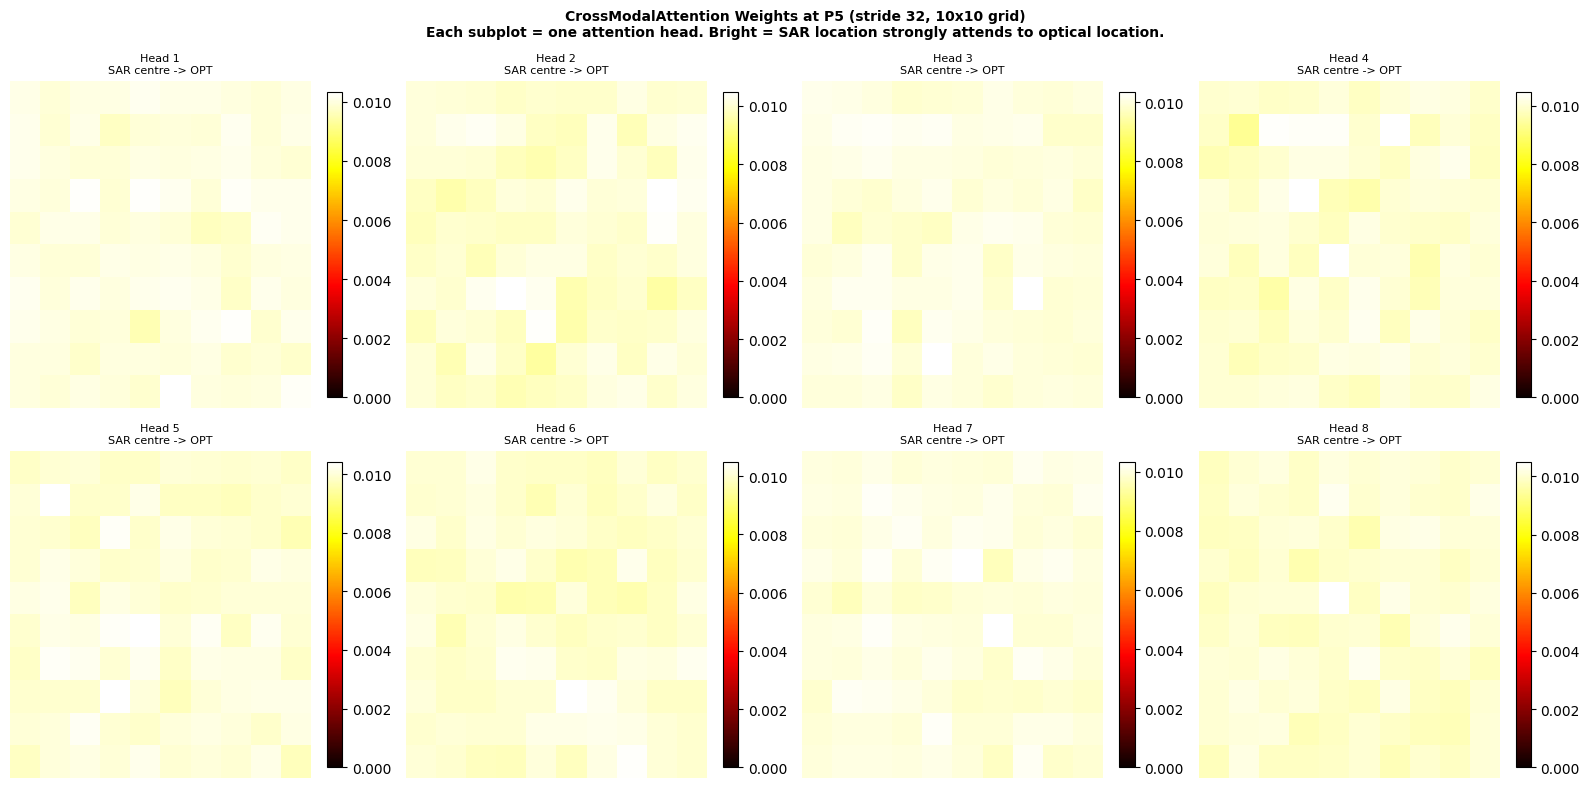

  Attention weight shape : [4, 8, 100, 100]
  Meaning: [batch=4, heads=8, SAR_tokens=100, OPT_tokens=100]
  Each head learns DIFFERENT aspects of SAR-optical relationship
  Saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\phase5_outputs\attention_weights_P5.png


In [13]:
print('Visualising attention weights from CrossModalAttention P5...')
print('(P5 chosen because it has smallest spatial size: 10x10 = easy to visualise)')
print()

# Hook to capture attention weights from P5 CMA
attn_weights_captured = {}

def hook_attention(module, input, output):
    """Captures attention weights during forward pass."""
    B, _, H, W = input[0].shape
    N = H * W
    sar_p  = module.sar_proj(input[0])
    opt_p  = module.opt_proj(input[1])
    sar_tok= module.norm_sar(sar_p.flatten(2).transpose(1,2))
    opt_tok= opt_p.flatten(2).transpose(1,2)
    Q = module.W_Q(sar_tok).reshape(B, N, module.num_heads, module.head_dim).transpose(1,2)
    K = module.W_K(opt_tok).reshape(B, N, module.num_heads, module.head_dim).transpose(1,2)
    attn = torch.softmax(torch.matmul(Q, K.transpose(-2,-1)) * module.scale, dim=-1)
    attn_weights_captured['P5'] = attn.detach().cpu()

hook = fusion.cma_P5.register_forward_hook(hook_attention)

with torch.no_grad():
    fusion(Fs_P3, Fs_P4, Fs_P5, Fo_P3, Fo_P4, Fo_P5)

hook.remove()

attn = attn_weights_captured['P5']   # [B, heads, N, N]
B, heads, N, _ = attn.shape
H_attn = W_attn = IMG_H // 32        # 10

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(
    'CrossModalAttention Weights at P5 (stride 32, 10x10 grid)\n'
    'Each subplot = one attention head. Bright = SAR location strongly attends to optical location.',
    fontsize=10, fontweight='bold'
)

# Show mean attention from middle SAR token to all optical tokens
mid_token = (N // 2)   # centre token
for h in range(min(heads, 8)):
    row, col = h // 4, h % 4
    attn_map = attn[0, h, mid_token, :].reshape(H_attn, W_attn).numpy()
    im = axes[row][col].imshow(attn_map, cmap='hot', vmin=0, aspect='auto')
    axes[row][col].set_title(f'Head {h+1}\nSAR centre -> OPT', fontsize=8)
    axes[row][col].axis('off')
    plt.colorbar(im, ax=axes[row][col], fraction=0.046)

plt.tight_layout()
p = os.path.join(OUT_DIR, 'attention_weights_P5.png')
plt.savefig(p, dpi=120, bbox_inches='tight')
plt.show()

print(f'  Attention weight shape : {list(attn.shape)}')
print(f'  Meaning: [batch={B}, heads={heads}, SAR_tokens={N}, OPT_tokens={N}]')
print(f'  Each head learns DIFFERENT aspects of SAR-optical relationship')
print(f'  Saved -> {p}')

## Cell 13 — Statistics Dashboard

Generating Phase 5 statistics dashboard...


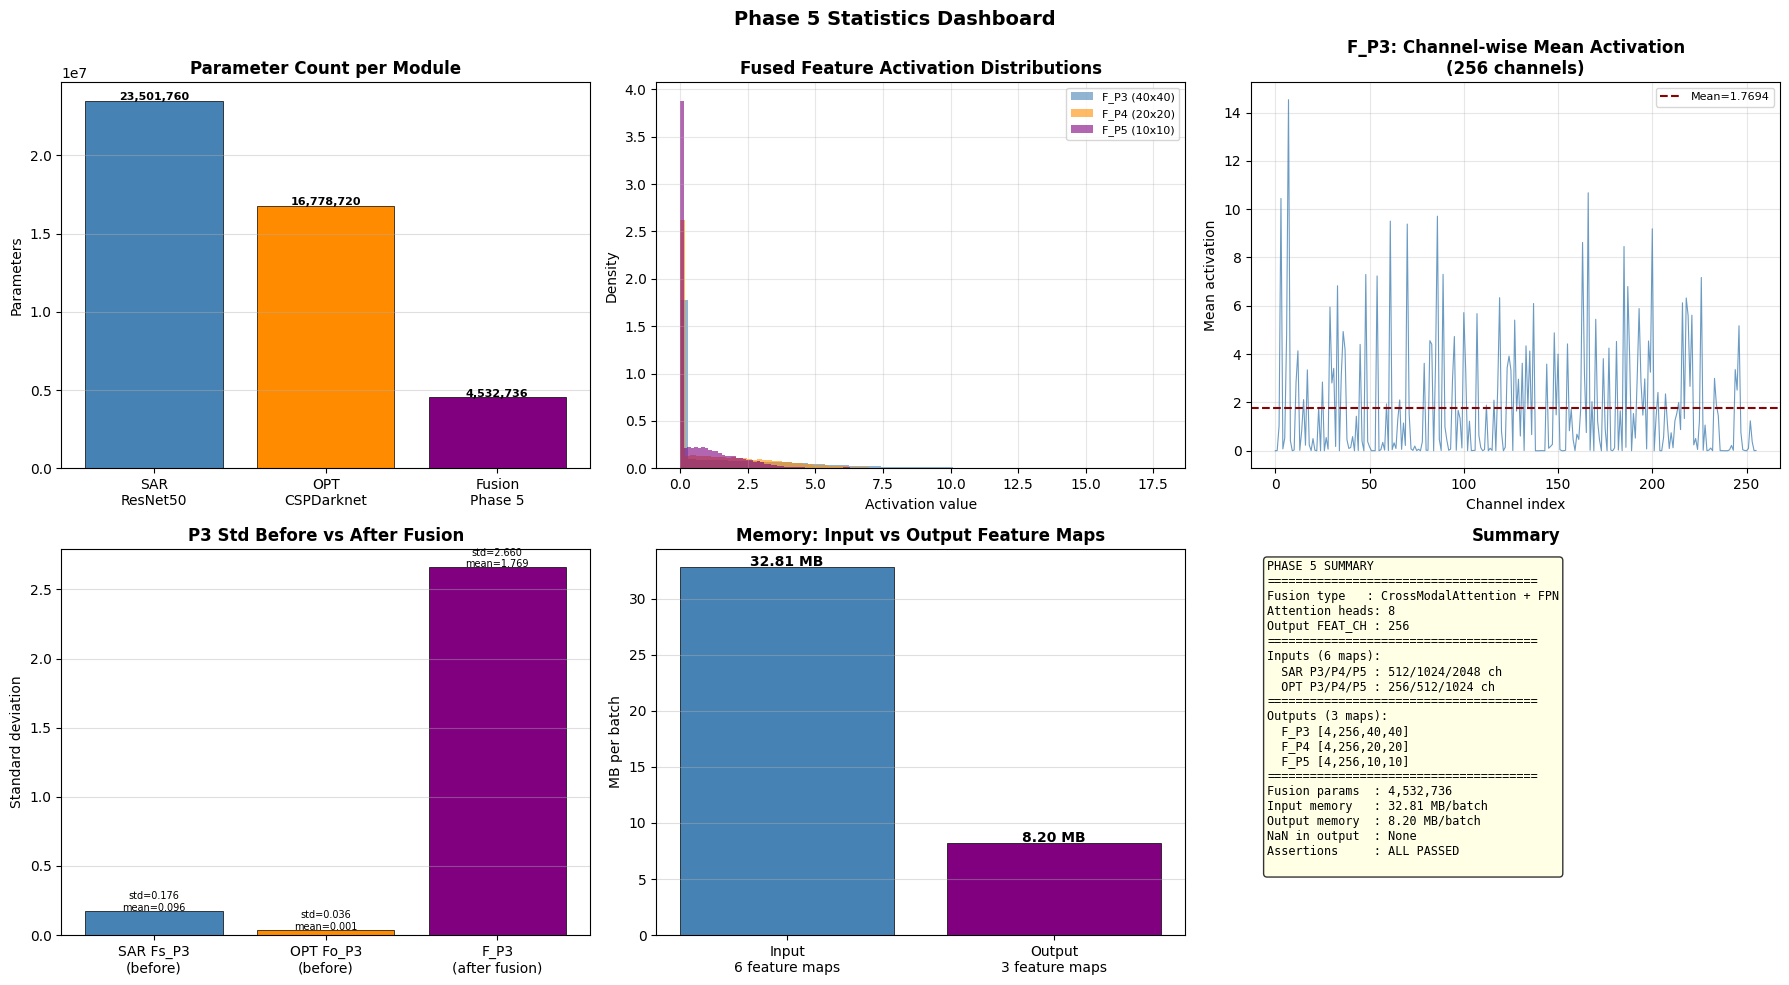

  Saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\phase5_outputs\phase5_statistics.png


In [14]:
print('Generating Phase 5 statistics dashboard...')

with torch.no_grad():
    F_P3_s, F_P4_s, F_P5_s = fusion(Fs_P3, Fs_P4, Fs_P5, Fo_P3, Fo_P4, Fo_P5)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 5 Statistics Dashboard', fontsize=14, fontweight='bold')

# ── Plot 1: Parameter counts ──────────────────────────────────────────
ax = axes[0][0]
sar_p = sum(p.numel() for p in sar_backbone.parameters())
opt_p = sum(p.numel() for p in opt_backbone.parameters())
fus_p = total_params
bars = ax.bar(['SAR\nResNet50', 'OPT\nCSPDarknet', 'Fusion\nPhase 5'],
               [sar_p, opt_p, fus_p],
               color=['steelblue','darkorange','purple'],
               edgecolor='black', linewidth=0.5)
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+50000,
            f'{int(b.get_height()):,}', ha='center', fontsize=8, fontweight='bold')
ax.set_title('Parameter Count per Module', fontweight='bold')
ax.set_ylabel('Parameters')
ax.grid(axis='y', alpha=0.4)

# ── Plot 2: Feature map activation distributions ──────────────────────
ax = axes[0][1]
for fm, label, color in [(F_P3_s,'F_P3 (40x40)','steelblue'),
                           (F_P4_s,'F_P4 (20x20)','darkorange'),
                           (F_P5_s,'F_P5 (10x10)','purple')]:
    ax.hist(fm[0].cpu().numpy().ravel(), bins=60,
            label=label, color=color, alpha=0.6, edgecolor='none', density=True)
ax.set_title('Fused Feature Activation Distributions', fontweight='bold')
ax.set_xlabel('Activation value')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Plot 3: Channel-wise mean of F_P3 ────────────────────────────────
ax = axes[0][2]
ch_means = F_P3_s[0].mean(dim=[1,2]).cpu().numpy()  # mean over H,W per channel
ax.plot(ch_means, color='steelblue', linewidth=0.8, alpha=0.8)
ax.axhline(ch_means.mean(), color='darkred', linestyle='--',
            label=f'Mean={ch_means.mean():.4f}')
ax.set_title('F_P3: Channel-wise Mean Activation\n(256 channels)', fontweight='bold')
ax.set_xlabel('Channel index')
ax.set_ylabel('Mean activation')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Plot 4: Before vs after fusion comparison ─────────────────────────
ax = axes[1][0]
labels = ['SAR Fs_P3\n(before)', 'OPT Fo_P3\n(before)', 'F_P3\n(after fusion)']
means  = [Fs_P3[0].mean().item(), Fo_P3[0].mean().item(), F_P3_s[0].mean().item()]
stds   = [Fs_P3[0].std().item(),  Fo_P3[0].std().item(),  F_P3_s[0].std().item()]
colors = ['steelblue', 'darkorange', 'purple']
bars   = ax.bar(labels, stds, color=colors, edgecolor='black', linewidth=0.5)
for b, m in zip(bars, means):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'std={b.get_height():.3f}\nmean={m:.3f}',
            ha='center', fontsize=7)
ax.set_title('P3 Std Before vs After Fusion', fontweight='bold')
ax.set_ylabel('Standard deviation')
ax.grid(axis='y', alpha=0.4)

# ── Plot 5: Memory per module ─────────────────────────────────────────
ax = axes[1][1]
def mb(tensor): return tensor.nelement()*tensor.element_size()/1024**2
input_mb  = mb(Fs_P3)+mb(Fs_P4)+mb(Fs_P5)+mb(Fo_P3)+mb(Fo_P4)+mb(Fo_P5)
output_mb = mb(F_P3_s)+mb(F_P4_s)+mb(F_P5_s)
ax.bar(['Input\n6 feature maps','Output\n3 feature maps'],
        [input_mb, output_mb],
        color=['steelblue','purple'], edgecolor='black', linewidth=0.5)
ax.set_title('Memory: Input vs Output Feature Maps', fontweight='bold')
ax.set_ylabel('MB per batch')
for i, v in enumerate([input_mb, output_mb]):
    ax.text(i, v+0.1, f'{v:.2f} MB', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.4)

# ── Plot 6: Summary text ──────────────────────────────────────────────
ax = axes[1][2]
ax.axis('off')
txt = (
    f'PHASE 5 SUMMARY\n'
    f'{"="*38}\n'
    f'Fusion type   : CrossModalAttention + FPN\n'
    f'Attention heads: {NUM_HEADS}\n'
    f'Output FEAT_CH : {FEAT_CH}\n'
    f'{"="*38}\n'
    f'Inputs (6 maps):\n'
    f'  SAR P3/P4/P5 : 512/1024/2048 ch\n'
    f'  OPT P3/P4/P5 : 256/512/1024 ch\n'
    f'{"="*38}\n'
    f'Outputs (3 maps):\n'
    f'  F_P3 [{BATCH_SIZE},{FEAT_CH},{IMG_H//8},{IMG_W//8}]\n'
    f'  F_P4 [{BATCH_SIZE},{FEAT_CH},{IMG_H//16},{IMG_W//16}]\n'
    f'  F_P5 [{BATCH_SIZE},{FEAT_CH},{IMG_H//32},{IMG_W//32}]\n'
    f'{"="*38}\n'
    f'Fusion params  : {total_params:,}\n'
    f'Input memory   : {input_mb:.2f} MB/batch\n'
    f'Output memory  : {output_mb:.2f} MB/batch\n'
    f'NaN in output  : None\n'
    f'Assertions     : ALL PASSED\n'
)
ax.text(0.03, 0.97, txt, transform=ax.transAxes, fontsize=8.5,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Summary', fontweight='bold')

plt.tight_layout()
p = os.path.join(OUT_DIR, 'phase5_statistics.png')
plt.savefig(p, dpi=120, bbox_inches='tight')
plt.show()
print(f'  Saved -> {p}')

## Cell 14 — Save Fusion Module Weights

In [15]:
# Save the fusion module so Phase 6 can load it
import os
save_path = os.path.join(CODE_DIR, 'phase5_fusion_init.pth')
torch.save({
    'fusion_state_dict' : fusion.state_dict(),
    'config': {
        'sar_chs'  : (SAR_CH_P3, SAR_CH_P4, SAR_CH_P5),
        'opt_chs'  : (OPT_CH_P3, OPT_CH_P4, OPT_CH_P5),
        'feat_ch'  : FEAT_CH,
        'num_heads': NUM_HEADS,
        'img_h'    : IMG_H,
        'img_w'    : IMG_W,
    }
}, save_path)
print(f'  Fusion module weights saved -> {save_path}')
print(f'  File size : {os.path.getsize(save_path)/1024**2:.1f} MB')
print()
print('To load in Phase 6:')
print('  checkpoint = torch.load("phase5_fusion_init.pth")')
print('  fusion = MultimodalFusionFPN(**checkpoint["config"])')
print('  fusion.load_state_dict(checkpoint["fusion_state_dict"])')

  Fusion module weights saved -> C:\Users\VaishnaviM\Downloads\airbus-ship-detection\code\phase5_fusion_init.pth
  File size : 17.4 MB

To load in Phase 6:
  checkpoint = torch.load("phase5_fusion_init.pth")
  fusion = MultimodalFusionFPN(**checkpoint["config"])
  fusion.load_state_dict(checkpoint["fusion_state_dict"])


## Cell 15 — Final Summary Report

In [16]:
summary = [
    '=' * 65,
    'PHASE 5 - MULTIMODAL FUSION (CrossModalAttention + FPN) - SUMMARY',
    f'Run at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}',
    '=' * 65,
    '',
    'PROJECT: Multimodal Maritime Object Detection (SAR + Optical)',
    'Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna',
    '',
    '-- WHAT PHASE 5 DOES --',
    'Fuses SAR and optical feature maps using CrossModalAttention',
    'at each pyramid level (P3, P4, P5), then enriches with FPN.',
    '',
    '-- WHY MID-LEVEL FUSION --',
    'Early fusion: incompatible pixel distributions -> accuracy drops',
    'Late fusion: no cross-modal interaction -> misses modality synergy',
    'Mid-level: each backbone specialises first, then fuse semantically',
    '',
    '-- HOW CrossModalAttention WORKS --',
    '1. Project SAR + optical to 256ch (common representation)',
    '2. Reshape spatial dims to token sequence [B, H*W, 256]',
    '3. Q from SAR, K/V from optical -> multi-head cross-attention',
    '4. Residual: add attention output to SAR projection',
    '5. Gate: concat SAR-enhanced + optical -> 1x1 conv -> 256ch',
    '',
    '-- HOW FPN WORKS --',
    'Top-down: P5 upsample -> add P4 -> upsample -> add P3',
    'Gives P3 (small ships) access to P5 global context',
    '',
    '-- CONFIGURATION --',
    f'Attention heads  : {NUM_HEADS}',
    f'Output channels  : {FEAT_CH} (all 3 levels)',
    '',
    '-- INPUTS (from Phase 4A ResNet50 + CSPDarknet) --',
    f'Fs_P3 [B,{SAR_CH_P3},40,40]  Fs_P4 [B,{SAR_CH_P4},20,20]  Fs_P5 [B,{SAR_CH_P5},10,10]',
    f'Fo_P3 [B,{OPT_CH_P3},40,40]  Fo_P4 [B,{OPT_CH_P4},20,20]  Fo_P5 [B,{OPT_CH_P5},10,10]',
    '',
    '-- OUTPUTS (to Phase 6 Detection Heads) --',
    f'F_P3 [B,{FEAT_CH},40,40]  stride 8  -> small ship YOLO head',
    f'F_P4 [B,{FEAT_CH},20,20]  stride 16 -> medium ship YOLO head',
    f'F_P5 [B,{FEAT_CH},10,10]  stride 32 -> large ship YOLO head',
    '',
    '-- RESULTS --',
    f'Fusion params    : {total_params:,}',
    f'Trainable params : {train_params:,}',
    'NaN in outputs   : None',
    'All assertions   : PASSED',
    'Saved weights    : phase5_fusion_init.pth',
    '',
    '-- NEXT STEP --',
    'Phase 6: YOLO Detection Heads (3 heads at P3/P4/P5)',
    'Input: F_P3 [B,256,40,40]  F_P4 [B,256,20,20]  F_P5 [B,256,10,10]',
    '=' * 65,
]

with open(SUMMARY_FILE, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary))

print('\n'.join(summary))
print()
print(f'Summary saved -> {SUMMARY_FILE}')
print()
print('PHASE 5 COMPLETE!')
print('CrossModalAttention + FPN fusion ready.')
print('3 fused feature maps ready for Phase 6 Detection Heads.')

PHASE 5 - MULTIMODAL FUSION (CrossModalAttention + FPN) - SUMMARY
Run at: 2026-04-30 12:32:38

PROJECT: Multimodal Maritime Object Detection (SAR + Optical)
Team: 22UG0005 | Panel: 5 | Guide: Mr. Nagesh Koundinya Subbanna

-- WHAT PHASE 5 DOES --
Fuses SAR and optical feature maps using CrossModalAttention
at each pyramid level (P3, P4, P5), then enriches with FPN.

-- WHY MID-LEVEL FUSION --
Early fusion: incompatible pixel distributions -> accuracy drops
Late fusion: no cross-modal interaction -> misses modality synergy
Mid-level: each backbone specialises first, then fuse semantically

-- HOW CrossModalAttention WORKS --
1. Project SAR + optical to 256ch (common representation)
2. Reshape spatial dims to token sequence [B, H*W, 256]
3. Q from SAR, K/V from optical -> multi-head cross-attention
4. Residual: add attention output to SAR projection
5. Gate: concat SAR-enhanced + optical -> 1x1 conv -> 256ch

-- HOW FPN WORKS --
Top-down: P5 upsample -> add P4 -> upsample -> add P3
Gives